<a href="https://colab.research.google.com/github/Najwaalya/PCVK_Ganjil_2025/blob/main/Modul10_Thresholding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Simple Threshold

In [34]:
from google.colab import drive
drive.mount('/content/drive')

import cv2 as cv
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
filename = ('/content/drive/MyDrive//PCVK/Images/gradient.jpg')
img = cv.imread(filename)
thresh = 127

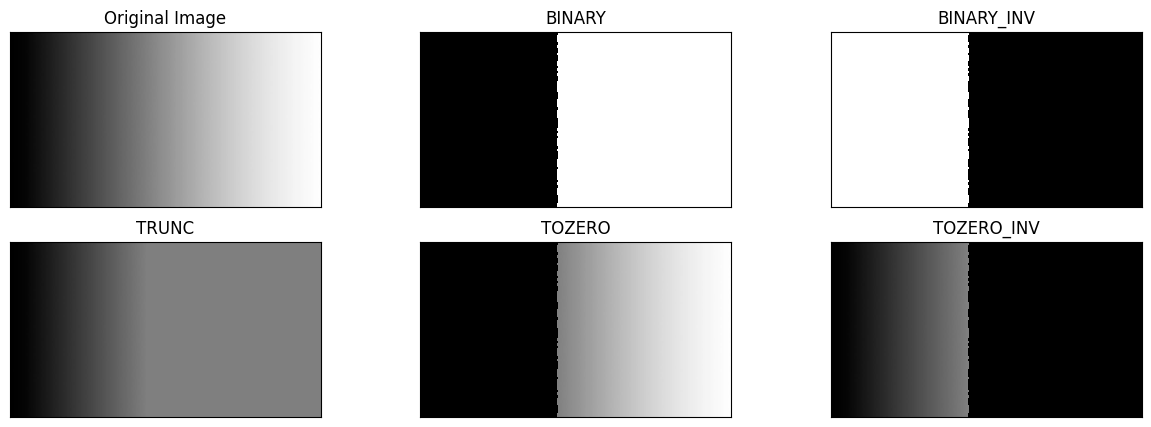

In [36]:
#1. thresh1 jika pixel di img>127, maka thresh1 bernilai 1(putih) selain itu bernilai 0(hitam)
ret,thresh1 = cv.threshold(img,thresh,255,cv.THRESH_BINARY)
#2. thresh2 adalah binary threshold inverse
ret,thresh2 = cv.threshold(img,thresh,255,cv.THRESH_BINARY_INV)
#3. Threshold Truncate
ret,thresh3 = cv.threshold(img,thresh,255,cv.THRESH_TRUNC)
#4. Threshold Tozero
ret,thresh4 = cv.threshold(img,thresh,255,cv.THRESH_TOZERO)
#5. Threshold Tozero Inverse
ret,thresh5 = cv.threshold(img,thresh,255,cv.THRESH_TOZERO_INV)

titles = ['Original Image','BINARY','BINARY_INV','TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

plt.figure(figsize = (15,5))
for i in range(len(images)):
  plt.subplot(2,3,i+1),plt.imshow(images[i],'gray', interpolation='nearest')
  plt.title(titles[i])
  plt.xticks([]),plt.yticks([])
plt.show()

## Adaptive Threshold

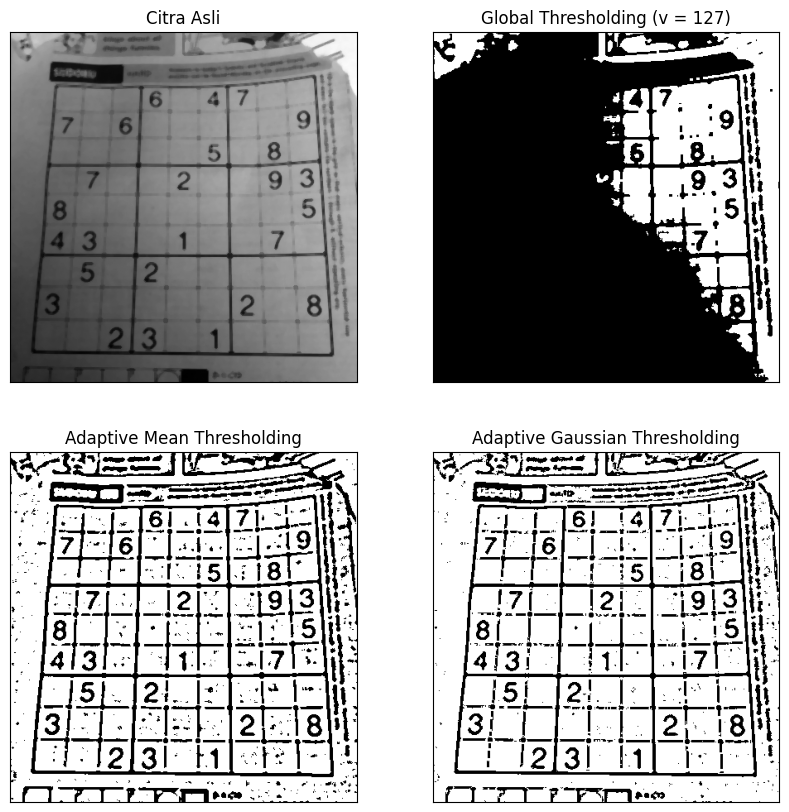

In [37]:
filename = ('/content/drive/MyDrive/PCVK/Images/sudoku-original.jpg')
citra = cv.medianBlur(cv.imread(filename),5)
gray = cv.cvtColor(citra, cv.COLOR_BGR2GRAY)
#gray = cv.medianBlur(gray,5)

thresh = 127

ret,th1 = cv.threshold(gray,thresh,255,cv.THRESH_BINARY)
th2 = cv.adaptiveThreshold(gray,255,cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY,11,2)
th3 = cv.adaptiveThreshold(gray,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY,11,2)

titles = ['Citra Asli', 'Global Thresholding (v = 127)', 'Adaptive Mean Thresholding', 'Adaptive Gaussian Thresholding']
citra2 = [gray, th1, th2, th3]

plt.figure(figsize = (10,10))
for i in range(len(citra2)):
    plt.subplot(2,2,i+1),plt.imshow(citra2[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

## Otsu's Threshold

/tmp/ipython-input-861158604.py:15: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(2,2,1),plt.hist(blur.ravel(),256,[50,200])


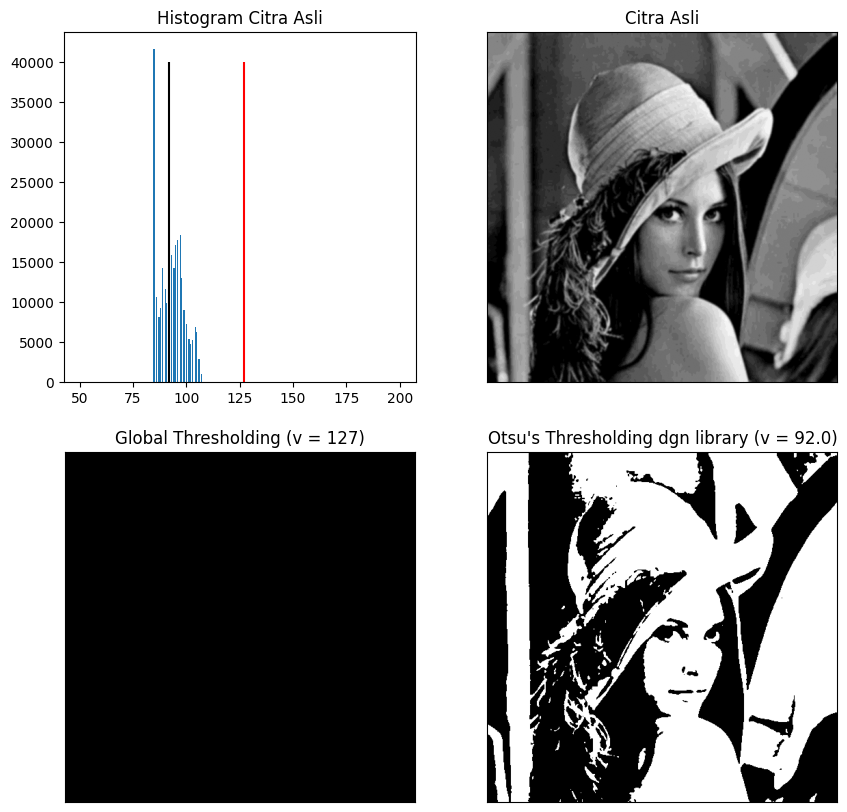

In [38]:
# Dengan Library
filename = ('/content/drive/MyDrive/PCVK/Images/lena_gs_lc2.jpg')
img = cv.imread(filename,0)
blur = cv.GaussianBlur(img,(5,5),0)
thresh = 127

ret,th1 = cv.threshold(blur,thresh,255,cv.THRESH_BINARY)
ret2,th2 = cv.threshold(blur,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)

x = ("Otsu's Thresholding dgn library (v = ")+str(ret2)+")"
titles = ['Citra Asli', 'Global Thresholding (v = 127)', x]
citra3 = [blur, th1, th2]

plt.figure(figsize = (10,10))
plt.subplot(2,2,1),plt.hist(blur.ravel(),256,[50,200])
plt.vlines(ret,0,40000,colors='red')     #garis vertikal merah menunjukan threshold global 127
plt.vlines(ret2,0,40000,colors='black')  #garis vertikal hitam menunjukkan threshold 92 hasil otsu's
plt.title('Histogram Citra Asli')
for i in range(len(citra3)):
    plt.subplot(2,2,i+2),plt.imshow(citra3[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

### threshold Otsu’s tanpa Gaussian Filter dan dengan menggunakan Gaussian Filter.

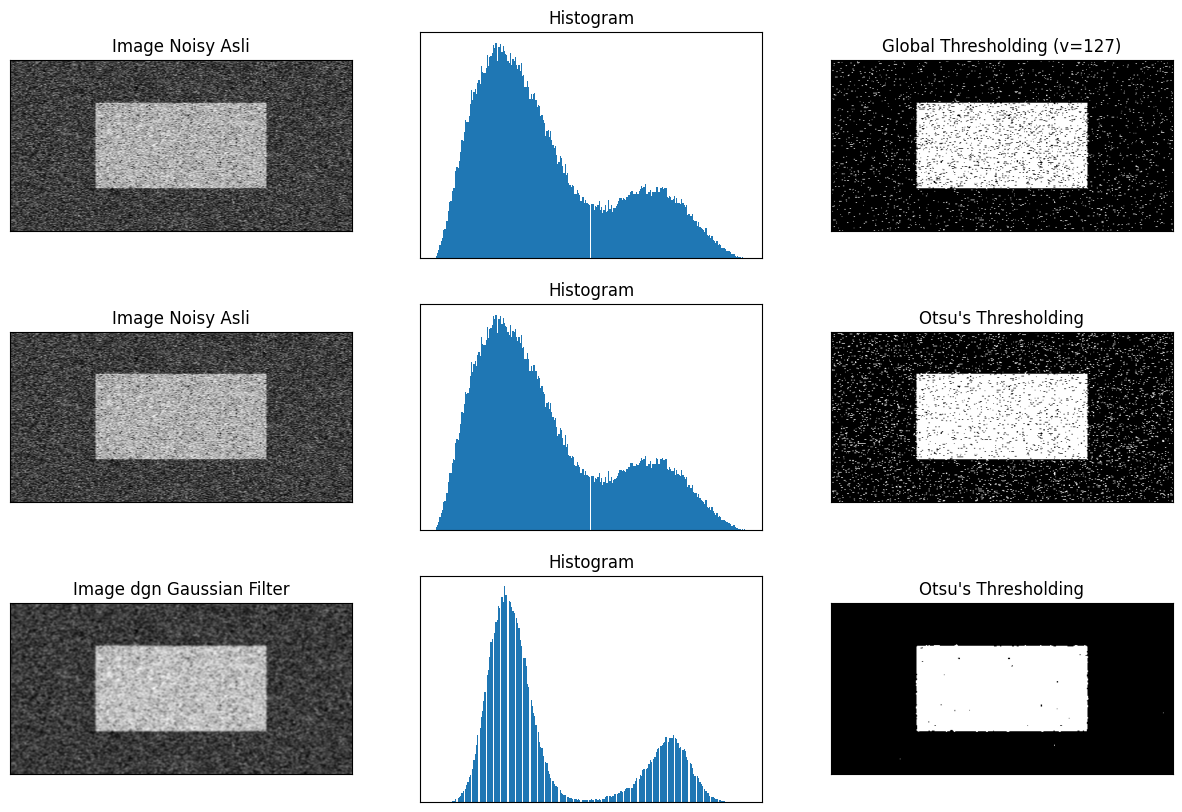

In [39]:
filename = ('/content/drive/MyDrive/PCVK/Images/noisy2.png')
img = cv.imread(filename,0)

#Global Thresholding
ret1,th1 = cv.threshold(img,127,255,cv.THRESH_BINARY)
# Otsu's thresholding
ret2,th2 = cv.threshold(img,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
# Otsu's thresholding setelah dilakukan Gaussian filtering
blur = cv.GaussianBlur(img,(5,5),0)
ret3,th3 = cv.threshold(blur,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
#plotting semua image
images = [img, 0, th1,
          img, 0, th2,
          blur, 0, th3]
titles = ['Image Noisy Asli','Histogram','Global Thresholding (v=127)',
          'Image Noisy Asli','Histogram',"Otsu's Thresholding",
          'Image dgn Gaussian Filter','Histogram',"Otsu's Thresholding"]
plt.figure(figsize = (15,10))
for i in range(3):
    plt.subplot(3,3,i*3+1),plt.imshow(images[i*3],'gray')
    plt.title(titles[i*3]), plt.xticks([]), plt.yticks([])
    plt.subplot(3,3,i*3+2),plt.hist(images[i*3].ravel(),256)
    plt.title(titles[i*3+1]), plt.xticks([]), plt.yticks([])
    plt.subplot(3,3,i*3+3),plt.imshow(images[i*3+2],'gray')
    plt.title(titles[i*3+2]), plt.xticks([]), plt.yticks([])
plt.show()


## Sementasi Citra menggunakan K-Means

(<Axes: >, <matplotlib.image.AxesImage at 0x7cdf793926f0>)

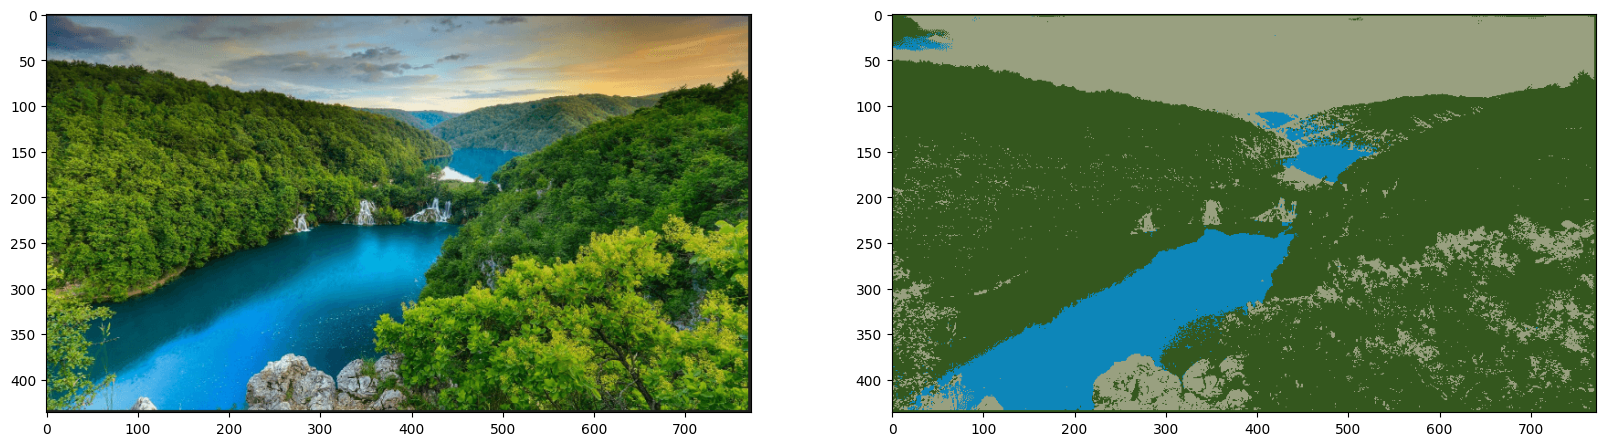

In [40]:
#KMeans Image Segmentation
filename = ('/content/drive/MyDrive/PCVK/Images/jungle.png')
img = cv.imread(filename)
img = cv.cvtColor(img,cv.COLOR_BGR2RGB)
'''
kita akan menggunakan fungsi cv.kmeans() yang meminta array 2D sebagai masu
 kan, sedangkan image aslinya adalah array 3D
selanjutnya kita perlu melakukan flattening array image masukan
'''
#reshape array ke bentuk 2D
pixel_values = img.reshape((-1, 3))
# convert to float
pixel_values = np.float32(pixel_values)

'''
syarat berhenti iterasi dr KMeans adalah jika centroid sudah tidak terlalu
banyak pergeseran posisi antara interasi sekarang
dengan iterasi sebelumnya (konvergen). Karena jumlah data yang besar, maka
kita akan hentikan iterasi saat jumlah iterasi = 100
atau epsilon(selisih antara posisi centroid skrg dgn posisi centroid di ite
 rasi sebelumnya) < 0.2
'''
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.2)
'''
jika diperhatikan pada image asli, terdapat 3 warna utama (hijau, biru, dan
 putih/orange). untuk percobaan ini kita akan gunakan
3 cluster untuk image ini
'''
k = 3
_, labels, (centers) = cv.kmeans(pixel_values, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)
#konversi titik centroid kedalam integer
centers = np.uint8(centers)
#flattening label array
labels = labels.flatten()
#konversi warna pixel asli kewarna dari tiap centroidnya
segmented_image = centers[labels.flatten()]
# reshape ke bentuk image asli
segmented_image = segmented_image.reshape(img.shape)
plt.figure(figsize = (20,20))
plt.subplot(1,2,1),plt.imshow(img)
plt.subplot(1,2,2),plt.imshow(segmented_image)

### dengan mengubah warna cluster tertentu

(<Axes: >, <matplotlib.image.AxesImage at 0x7cdf8049ca70>)

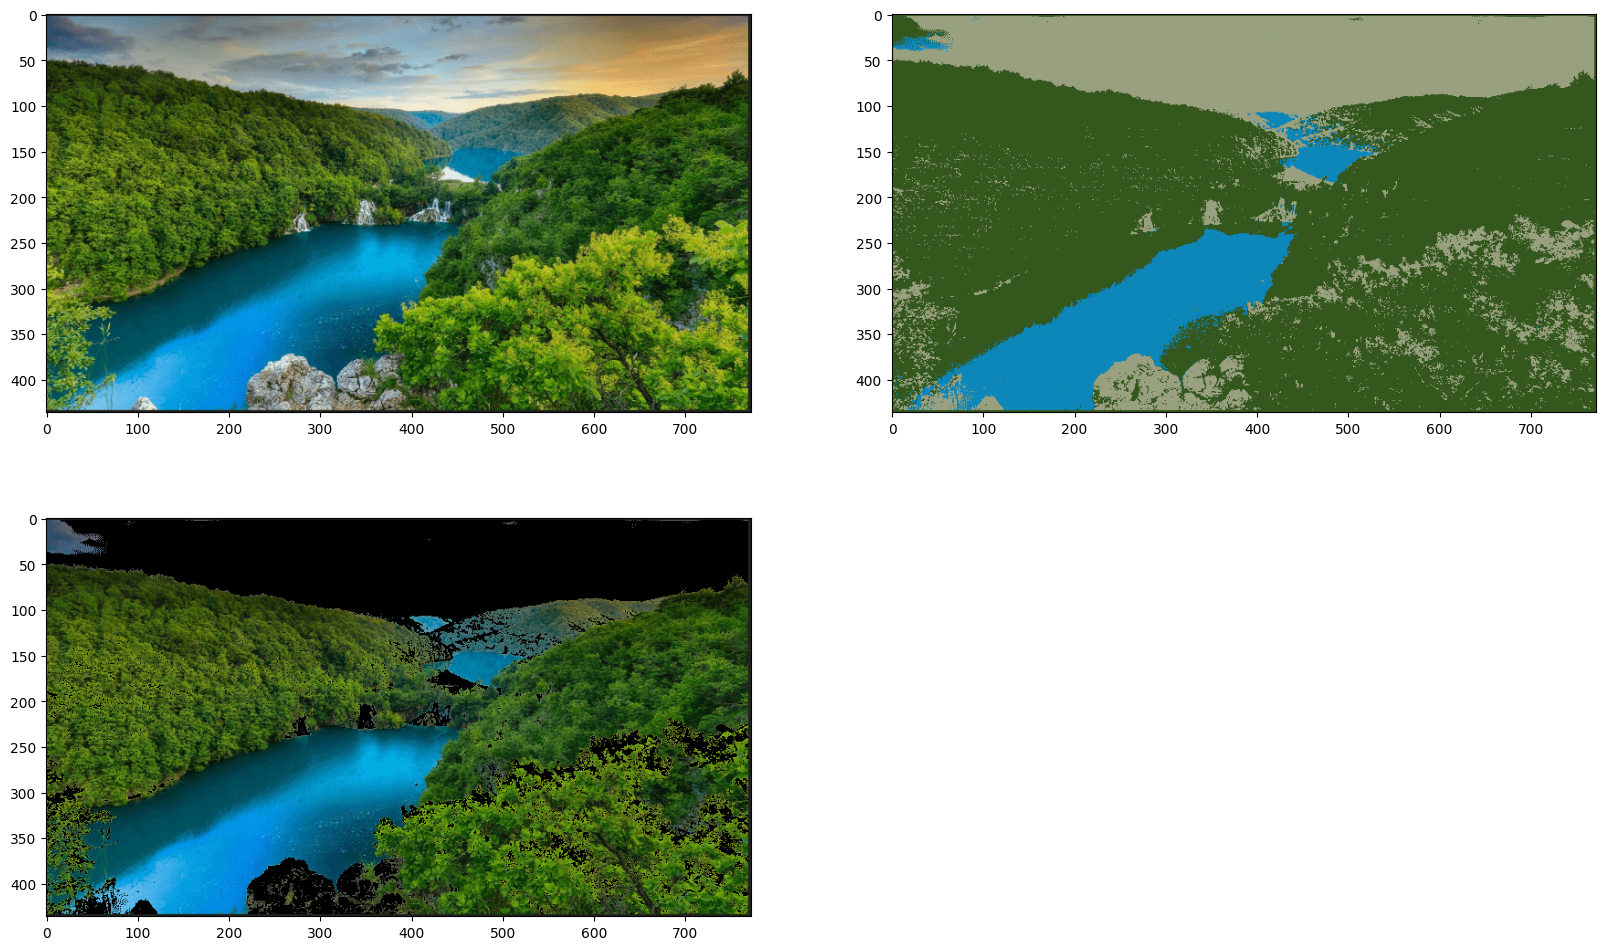

In [41]:
#KMeans Image Segmentation
filename = ('/content/drive/MyDrive/PCVK/Images/jungle.png')
img = cv.imread(filename)
img = cv.cvtColor(img,cv.COLOR_BGR2RGB)
'''
kita akan menggunakan fungsi cv.kmeans() yang meminta array 2D sebagai masu
 kan, sedangkan image aslinya adalah array 3D
selanjutnya kita perlu melakukan flattening array image masukan
'''
#reshape array ke bentuk 2D
pixel_values = img.reshape((-1, 3))
# convert to float
pixel_values = np.float32(pixel_values)

'''
syarat berhenti iterasi dr KMeans adalah jika centroid sudah tidak terlalu
banyak pergeseran posisi antara interasi sekarang
dengan iterasi sebelumnya (konvergen). Karena jumlah data yang besar, maka
kita akan hentikan iterasi saat jumlah iterasi = 100
atau epsilon(selisih antara posisi centroid skrg dgn posisi centroid di ite
 rasi sebelumnya) < 0.2
'''
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.2)
'''
jika diperhatikan pada image asli, terdapat 3 warna utama (hijau, biru, dan
 putih/orange). untuk percobaan ini kita akan gunakan
3 cluster untuk image ini
'''

# ubah pixel di cluster 2 menjadi hitam
masked_image = np.copy(img)
# konvert ke bentuk vektor
masked_image = masked_image.reshape((-1, 3))
# cluster yang diubah
cluster = 2
masked_image[labels == cluster] = [0, 0, 0]
# konvert ke bentuk asli
masked_image = masked_image.reshape(img.shape)

plt.figure(figsize = (20,12))
plt.subplot(2,2,1),plt.imshow(img)
plt.subplot(2,2,2),plt.imshow(segmented_image)
plt.subplot(2,2,3),plt.imshow(masked_image)

# TUGAS PRAKTIKUM

## Global Threshold (5 jenis, T = 170)

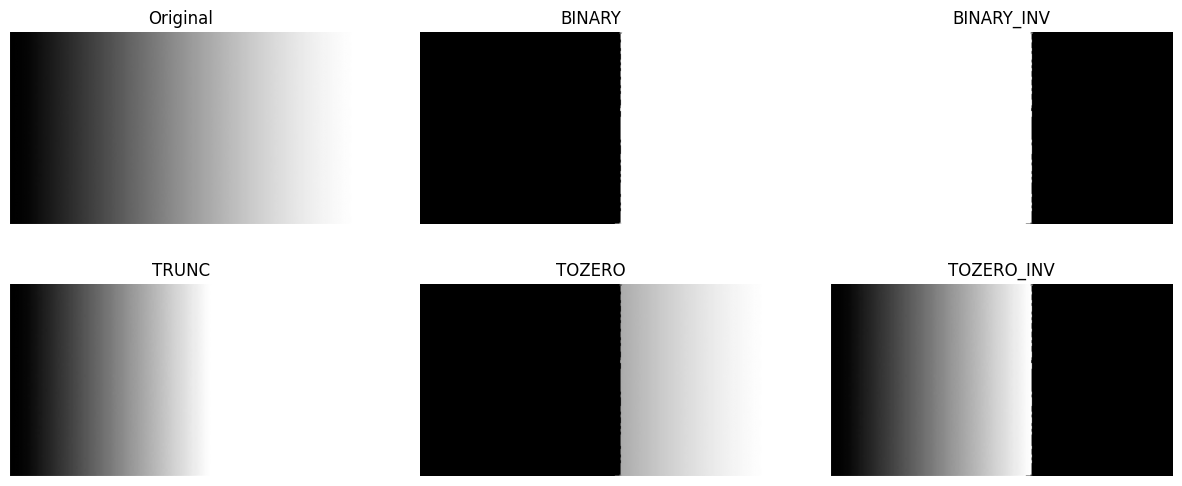

In [42]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/gradient.jpg', cv.IMREAD_GRAYSCALE)
th = 170
_, th1 = cv.threshold(img, th, 255, cv.THRESH_BINARY)
_, th2 = cv.threshold(img, th, 255, cv.THRESH_BINARY_INV)
_, th3 = cv.threshold(img, th, 255, cv.THRESH_TRUNC)
_, th4 = cv.threshold(img, th, 255, cv.THRESH_TOZERO)
_, th5 = cv.threshold(img, th, 255, cv.THRESH_TOZERO_INV)

titles = ['Original','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
images = [img, th1, th2, th3, th4, th5]

plt.figure(figsize=(15,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()

## Otsu Threshold Manual + Perbandingan

Threshold Otsu manual = 185


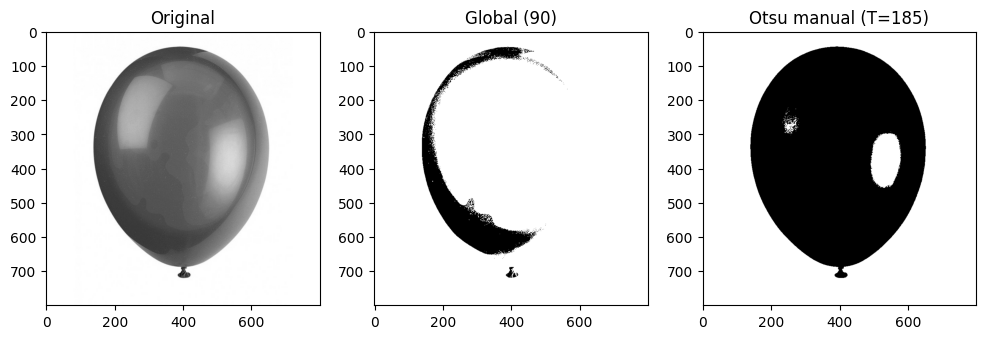

In [43]:
def otsu_manual(gray):
    hist = cv.calcHist([gray],[0],None,[256],[0,256]).flatten()
    total = gray.size
    p = hist/total
    omega = np.cumsum(p)
    mu = np.cumsum(p*np.arange(256))
    mu_t = mu[-1]
    sigma_b2 = (mu_t*omega - mu)**2 / (omega*(1-omega)+1e-12)
    best_t = np.argmax(sigma_b2)
    _, th_img = cv.threshold(gray, best_t, 255, cv.THRESH_BINARY)
    return best_t, th_img

balloon = cv.imread('/content/drive/MyDrive/PCVK/Images/balloon.jpg', cv.IMREAD_GRAYSCALE)
_, th_global = cv.threshold(balloon,90,255,cv.THRESH_BINARY)
best_t, th_otsu = otsu_manual(balloon)
print("Threshold Otsu manual =", best_t)

plt.figure(figsize=(12,6))
plt.subplot(1,3,1); plt.imshow(balloon,cmap='gray'); plt.title('Original')
plt.subplot(1,3,2); plt.imshow(th_global,cmap='gray'); plt.title('Global (90)')
plt.subplot(1,3,3); plt.imshow(th_otsu,cmap='gray'); plt.title(f'Otsu manual (T={best_t})')
plt.show()

## Histogram Foreground (tobacco.jpg)

Nilai threshold Otsu = 188.0


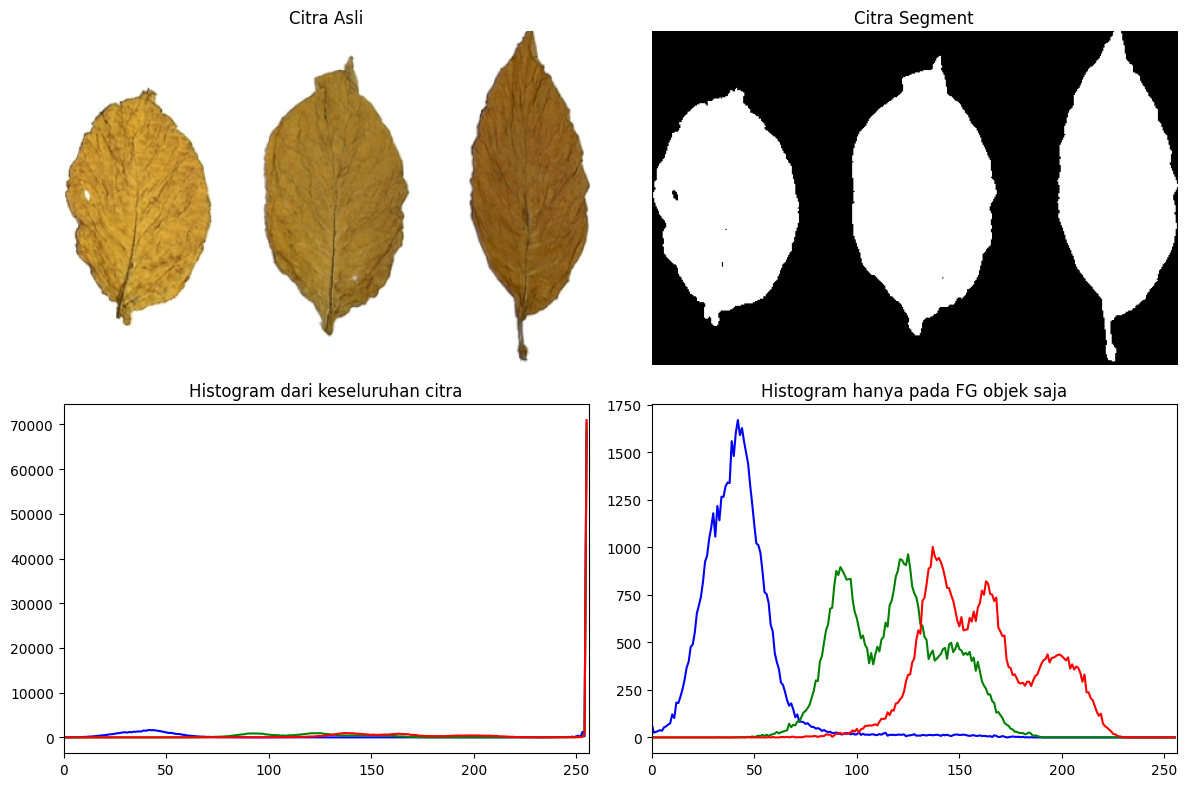

In [46]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# === 1. Baca gambar ===
img = cv.imread('/content/drive/MyDrive/PCVK/Images/tobacco.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# === 2. Threshold Otsu (pakai inverse biar daun putih, background hitam) ===
ret, mask = cv.threshold(gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
print(f"Nilai threshold Otsu = {ret}")

# === 3. Hitung histogram ===
colors = ('b', 'g', 'r')

# Histogram keseluruhan citra (mask=None)
hist_all = [cv.calcHist([img],[i],None,[256],[0,256]) for i in range(3)]

# Histogram hanya foreground (mask putih)
hist_fg = [cv.calcHist([img],[i],mask,[256],[0,256]) for i in range(3)]

# === 4. Tampilkan hasil ===
plt.figure(figsize=(12,8))

# (1) Citra Asli
plt.subplot(2,2,1)
plt.imshow(img_rgb)
plt.title('Citra Asli')
plt.axis('off')

# (2) Citra Segment
plt.subplot(2,2,2)
plt.imshow(mask, cmap='gray')
plt.title('Citra Segment')
plt.axis('off')

# (3) Histogram keseluruhan citra
plt.subplot(2,2,3)
for i, col in enumerate(colors):
    plt.plot(hist_all[i], color=col)
plt.title('Histogram dari keseluruhan citra')
plt.xlim([0,256])

# (4) Histogram FG saja (mask putih)
plt.subplot(2,2,4)
for i, col in enumerate(colors):
    plt.plot(hist_fg[i], color=col)
plt.title('Histogram hanya pada FG objek saja')
plt.xlim([0,256])

plt.tight_layout()
plt.show()

## Segmentasi Warna Kuning (peppers.jpg) dengan K-Means

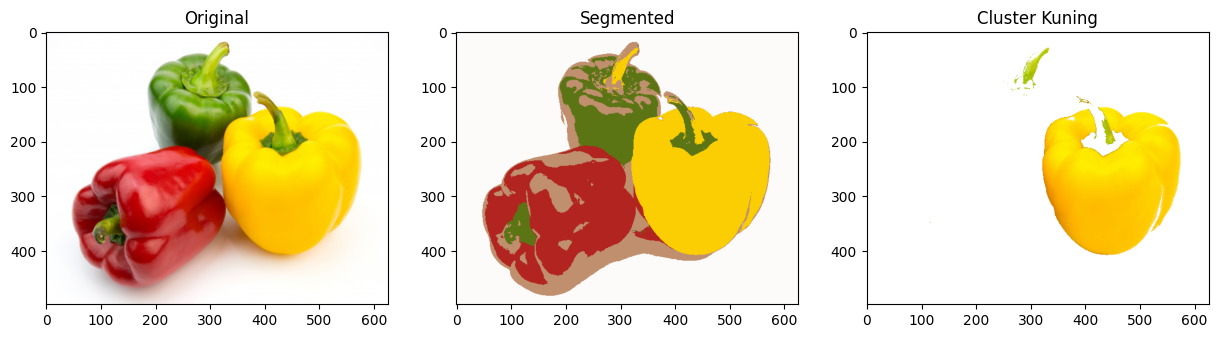

In [51]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/peppers.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

pixels = np.float32(img_rgb.reshape(-1,3))
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER,100,0.2)
k = 5
_, labels, centers = cv.kmeans(pixels, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)
centers = np.uint8(centers)
labels = labels.flatten()
segmented = centers[labels].reshape(img_rgb.shape)

yellow_ref = np.array([255,255,0])
dists = np.linalg.norm(centers - yellow_ref, axis=1)
yellow_cluster = np.argmin(dists)
mask = (labels == yellow_cluster).astype(np.uint8)*255
mask = mask.reshape(img_rgb.shape[:2])

masked = np.ones_like(img_rgb) * 255
masked[mask==255] = img_rgb[mask==255]

plt.figure(figsize=(15,6))
plt.subplot(1,3,1); plt.imshow(img_rgb); plt.title('Original')
plt.subplot(1,3,2); plt.imshow(segmented); plt.title('Segmented')
plt.subplot(1,3,3); plt.imshow(masked); plt.title('Cluster Kuning')
plt.show()

Centers (RGB):
[[250 206   3]
 [178  36  31]
 [ 92 117  20]
 [192 143 110]
 [252 251 249]]
Cluster merah = 1, hijau = 2


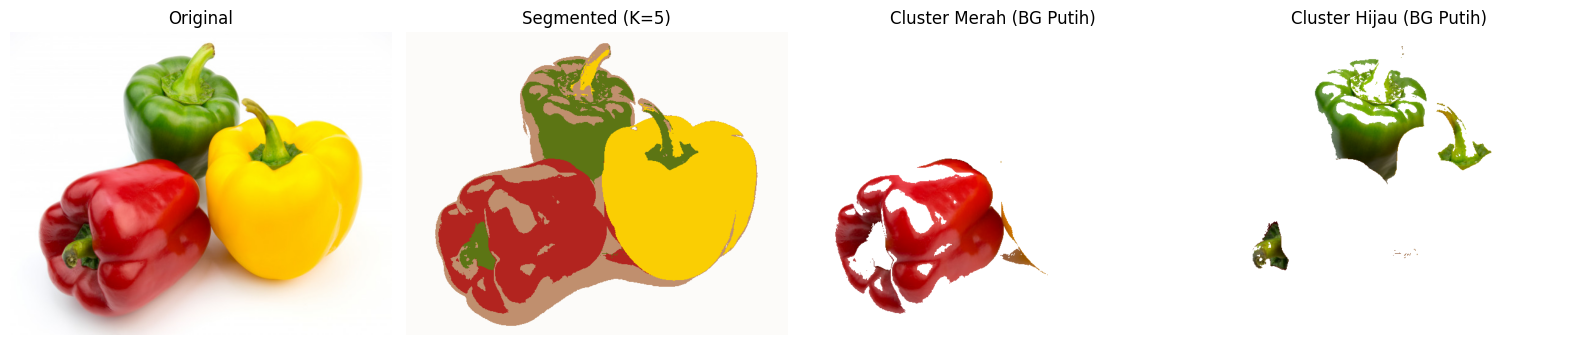

In [53]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# === 1. Baca gambar ===
img = cv.imread('/content/drive/MyDrive/PCVK/Images/peppers.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# === 2. K-Means Clustering ===
pixels = np.float32(img_rgb.reshape(-1,3))
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER,100,0.2)
k = 5  # jumlah cluster
_, labels, centers = cv.kmeans(pixels, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)
centers = np.uint8(centers)
labels = labels.flatten()
segmented = centers[labels].reshape(img_rgb.shape)

# === 3. Cari cluster paling mendekati warna merah dan hijau ===
red_ref = np.array([255, 0, 0])
green_ref = np.array([0, 255, 0])

dist_red = np.linalg.norm(centers - red_ref, axis=1)
dist_green = np.linalg.norm(centers - green_ref, axis=1)

red_cluster = np.argmin(dist_red)
green_cluster = np.argmin(dist_green)

print("Centers (RGB):")
print(centers)
print(f"Cluster merah = {red_cluster}, hijau = {green_cluster}")

# === 4. Buat mask merah dan hijau ===
mask_red = (labels == red_cluster).astype(np.uint8)*255
mask_green = (labels == green_cluster).astype(np.uint8)*255

mask_red = mask_red.reshape(img_rgb.shape[:2])
mask_green = mask_green.reshape(img_rgb.shape[:2])

# === 5. Buat hasil akhir: hanya warna yang dipilih yang ditampilkan ===
masked_red = np.ones_like(img_rgb)*255
masked_green = np.ones_like(img_rgb)*255

masked_red[mask_red==255] = img_rgb[mask_red==255]
masked_green[mask_green==255] = img_rgb[mask_green==255]

# === 6. Tampilkan hasil ===
plt.figure(figsize=(16,6))

plt.subplot(1,4,1)
plt.imshow(img_rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(segmented)
plt.title('Segmented (K=5)')
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(masked_red)
plt.title('Cluster Merah (BG Putih)')
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(masked_green)
plt.title('Cluster Hijau (BG Putih)')
plt.axis('off')

plt.tight_layout()
plt.show()

Saat anda menampilkan warna tertentu, jelaskan kendala yang di hadapi dan mengapa hal itu terjadi.
- Kendala yang dihadapi saat menampilkan warna tertentu adalah hasil segmentasi sering tidak akurat karena adanya gradasi warna dan pencahayaan yang tidak merata. Warna lain yang mirip juga dapat ikut terdeteksi karena keterbatasan pemisahan warna pada ruang RGB. Selain itu, pemilihan jumlah cluster (K) sangat memengaruhi ketepatan hasil segmentasi.

## Thresholding Terbaik (crossword.jpg)

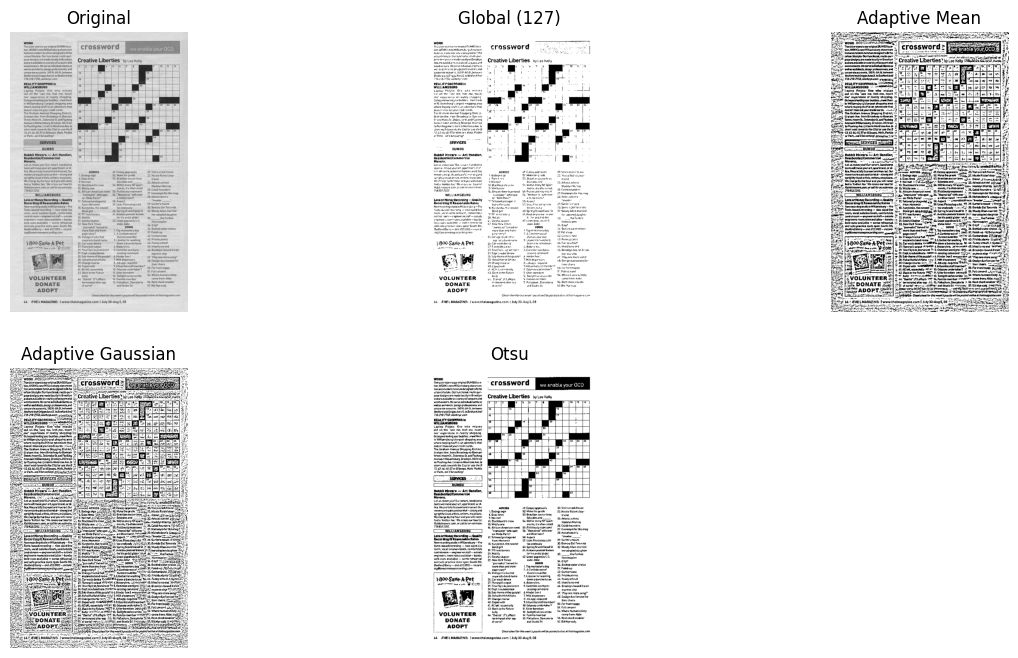

In [52]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/crossword.jpg', cv.IMREAD_GRAYSCALE)
_, th_global = cv.threshold(img,127,255,cv.THRESH_BINARY)
th_mean = cv.adaptiveThreshold(img,255,cv.ADAPTIVE_THRESH_MEAN_C,cv.THRESH_BINARY,11,2)
th_gauss = cv.adaptiveThreshold(img,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C,cv.THRESH_BINARY,11,2)
_, th_otsu = cv.threshold(img,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)

plt.figure(figsize=(15,8))
titles = ['Original','Global (127)','Adaptive Mean','Adaptive Gaussian','Otsu']
images = [img, th_global, th_mean, th_gauss, th_otsu]
for i in range(5):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i],cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()

Perbandingan Hasil Thresholding

Global Threshold (127):

- Menggunakan satu nilai ambang untuk seluruh gambar.
- Hasil kurang baik karena pencahayaan tidak merata, beberapa bagian terlalu gelap atau terlalu terang.

Adaptive Mean Threshold:

- Menentukan ambang berdasarkan rata-rata lokal tiap area kecil.
- Hasil cukup baik, pola kotak terlihat, namun muncul sedikit noise di area terang.

Adaptive Gaussian Threshold:

- Menggunakan bobot Gaussian untuk menentukan ambang setiap area.
- Hasil paling baik, detail pola kotak jelas dan kontras merata di seluruh gambar.

Otsu’s Threshold:

- Menentukan ambang otomatis dari histogram global.
- Hasil lumayan, tetapi tidak sebersih adaptive karena pengaruh pencahayaan tidak merata.

**Metode Adaptive Gaussian Thresholding memberikan hasil terbaik karena mampu menyesuaikan nilai ambang di setiap area gambar, sehingga menghasilkan citra yang lebih kontras dan detail tanpa banyak noise.**